In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

### check_columns ("기존 파일", "새 파일")
컬럼의 수 비교 후, 빠진 것과 추가 된 것 표시

In [13]:
import pandas as pd

result = {}

check_columns( "smartfarm_code/output/selected_smartfarm.csv",
               "C:/Users/ui203/OneDrive/문서/green_project/output/smartfarm_20260401.csv" )

def check_columns(baseline_path: str, new_path: str):
    global result

    def load_cols(path):
        if path.endswith(".csv"):
            return set(pd.read_csv(path, nrows=0).columns.tolist())
        else:
            return set(pd.read_excel(path, nrows=0).columns.tolist())

    baseline_cols = load_cols(baseline_path)
    new_cols = load_cols(new_path)

    missing = sorted(baseline_cols - new_cols)
    extra   = sorted(new_cols - baseline_cols)
    matched = sorted(baseline_cols & new_cols)

    result = {
        "missing": missing,
        "extra": extra,
        "matched": matched
    }

    print("=" * 55)
    print(f"기준: {baseline_path} ({len(baseline_cols)}개)")
    print(f"신규: {new_path} ({len(new_cols)}개)")
    print("=" * 55)

    if not missing and not extra:
        print("✅ 완전 일치 — 컬럼 변동 없음")
    else:
        if missing:
            print(f"\n❌ 빠진 컬럼 ({len(missing)}개)")
            for c in missing:
                print(f"  - {c}")
        if extra:
            print(f"\n➕ 추가된 컬럼 ({len(extra)}개)")
            for c in extra:
                print(f"  + {c}")

    print(f"\n✔ 일치: {len(matched)}개")

기준: smartfarm_code/output/selected_smartfarm.csv (45개)
신규: C:/Users/ui203/OneDrive/문서/green_project/output/smartfarm_20260401.csv (115개)

➕ 추가된 컬럼 (70개)
  + acid_tank_est_hours_to_empty
  + acoustic_db
  + active_zone_count
  + agitator_current_a
  + agitator_rpm
  + anomaly_label
  + anomaly_severity
  + anomaly_type
  + bearing_vibration_peak_mm_s
  + cavitation_index
  + clogging_index
  + crop_stage
  + daily_light_integral_mol_m2_d
  + daily_light_integral_proxy
  + day_index
  + dehumidifier_state
  + differential_pressure_kpa
  + dosing_a_ml_min
  + dosing_b_ml_min
  + dp_per_flow
  + drainage_ratio_pct
  + external_humidity_pct
  + external_temp_c
  + fault_history_24h_min
  + filter_delta_p_kpa
  + flow_baseline_l_min
  + flow_cv_15m
  + flow_drop_rate
  + flow_per_power
  + flow_std_15m
  + hour
  + hydraulic_power_kw
  + lights_on
  + minute_of_day
  + mixing_efficiency
  + mixing_uniformity_cv
  + pid_error_ec
  + pid_error_ph
  + pressure_flow_ratio
  + pressure_iqr_15m
  

In [27]:
df_model = raw.copy()

base_exclude_cols = [
    "timestamp"
]

zone_exclude_cols = [
    c for c in df_model.columns
    if c.lower().startswith("zone1_") or c.lower().startswith("zone3_")
]

train_exclude_cols = base_exclude_cols + zone_exclude_cols

X = (
    df_model
    .drop(columns=train_exclude_cols, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

print("X shape:", X.shape)
print("남은 zone 관련 컬럼:")
print([c for c in X.columns if c.lower().startswith("zone")])

display(X.head())

X shape: (12960, 34)
남은 zone 관련 컬럼:
['zone2_flow_l_min', 'zone2_pressure_kpa', 'zone2_substrate_moisture_pct', 'zone2_substrate_ec_ds_m', 'zone2_substrate_ph']


,light_ppfd_umol_m2_s,air_temp_c,relative_humidity_pct,co2_ppm,raw_tank_level_pct,raw_water_temp_c,pump_rpm,flow_rate_l_min,suction_pressure_kpa,discharge_pressure_kpa,motor_current_a,motor_power_kw,bearing_vibration_rms_mm_s,motor_temperature_c,bearing_temperature_c,filter_pressure_in_kpa,filter_pressure_out_kpa,turbidity_ntu,mix_target_ec_ds_m,mix_ec_ds_m,mix_target_ph,mix_ph,mix_temp_c,mix_flow_l_min,dosing_acid_ml_min,drain_ec_ds_m,tank_a_level_pct,tank_b_level_pct,acid_tank_level_pct,zone2_flow_l_min,zone2_pressure_kpa,zone2_substrate_moisture_pct,zone2_substrate_ec_ds_m,zone2_substrate_ph
0,2.772,17.530,78.083,466.921,80.004,16.605,0.000,0.048,0.042,3.324,0.108,0.020,0.099,39.769,38.179,2.188,1.952,1.058,2.18,2.182,5.8,5.792,17.506,0.078,0.185,2.415,87.261,86.144,82.648,0.025,1.478,58.892,2.324,5.837
1,0.000,17.570,80.394,456.254,80.962,17.005,0.000,0.069,-0.071,3.146,0.065,0.010,0.099,39.897,38.148,2.531,2.303,1.140,2.18,2.188,5.8,5.804,17.879,0.069,0.114,2.384,87.961,86.299,82.657,0.000,1.294,59.045,2.332,5.832
2,18.679,17.835,78.922,446.334,80.429,16.872,0.000,0.057,-0.356,2.689,0.049,0.026,0.188,39.906,38.310,2.423,2.204,1.121,2.18,2.181,5.8,5.804,17.898,0.069,0.120,2.423,87.148,86.671,82.639,0.012,2.092,58.771,2.324,5.824
3,1.236,17.964,77.905,472.824,81.172,16.820,1.739,0.047,-0.095,3.193,0.104,0.031,0.105,39.852,38.390,2.675,2.436,1.307,2.18,2.190,5.8,5.805,17.791,0.023,0.147,2.418,87.948,86.221,82.602,0.015,1.774,59.346,2.358,5.831
4,22.049,17.475,78.655,471.147,81.688,16.942,2.352,0.014,-0.125,3.131,0.043,0.004,0.211,39.862,38.249,2.395,2.115,1.307,2.18,2.187,5.8,5.803,17.772,0.003,0.161,2.424,88.416,87.355,82.576,0.007,2.251,59.319,2.324,5.833


In [21]:
# 기본 제외 컬럼
base_exclude_cols = [
    "timestamp",
    "cleaning_event_flag",
    "hidden_tip_clog_level",
    "hidden_blocked_tip_ratio",
    "hidden_risk_stage"
]

# zone1, zone3만 제외하고 zone2는 남김
zone_exclude_cols = [
    c for c in df_model.columns
    if c.lower().startswith("zone1_") or c.lower().startswith("zone3_")
]

train_exclude_cols = base_exclude_cols + zone_exclude_cols

print("기본 제외 컬럼:")
print(base_exclude_cols)

print("\nzone 제외 컬럼:")
print(zone_exclude_cols)

print("\n최종 학습 제외 컬럼 수:", len(train_exclude_cols))

기본 제외 컬럼:
['timestamp', 'cleaning_event_flag', 'hidden_tip_clog_level', 'hidden_blocked_tip_ratio', 'hidden_risk_stage']

zone 제외 컬럼:
['zone1_flow_l_min', 'zone1_pressure_kpa', 'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m', 'zone1_substrate_ph', 'zone3_flow_l_min', 'zone3_pressure_kpa', 'zone3_substrate_moisture_pct', 'zone3_substrate_ec_ds_m', 'zone3_substrate_ph']

최종 학습 제외 컬럼 수: 15


In [3]:
import pandas as pd

# 원본 로드
df_raw = pd.read_csv("smartfarm_code/output/selected_smartfarm.csv", encoding="utf-8-sig")

# zone1, zone3 컬럼만 추출
ZONE_DROP = [
    c for c in df_raw.columns
    if c.lower().startswith("zone1_") or c.lower().startswith("zone3_")
]

print("제거할 zone 컬럼:")
print(ZONE_DROP)

# 메모리에서만 제거
df_raw = df_raw.drop(columns=ZONE_DROP, errors="ignore")

print("\n남은 zone 컬럼:")
print([c for c in df_raw.columns if c.lower().startswith("zone")])

print("\ndf_raw shape:", df_raw.shape)
display(df_raw.head())

제거할 zone 컬럼:
['zone1_flow_l_min', 'zone1_pressure_kpa', 'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m', 'zone1_substrate_ph', 'zone3_flow_l_min', 'zone3_pressure_kpa', 'zone3_substrate_moisture_pct', 'zone3_substrate_ec_ds_m', 'zone3_substrate_ph']

남은 zone 컬럼:
['zone2_flow_l_min', 'zone2_pressure_kpa', 'zone2_substrate_moisture_pct', 'zone2_substrate_ec_ds_m', 'zone2_substrate_ph']

df_raw shape: (12960, 35)


,timestamp,light_ppfd_umol_m2_s,air_temp_c,relative_humidity_pct,co2_ppm,raw_tank_level_pct,raw_water_temp_c,pump_rpm,flow_rate_l_min,suction_pressure_kpa,...,dosing_acid_ml_min,drain_ec_ds_m,tank_a_level_pct,tank_b_level_pct,acid_tank_level_pct,zone2_flow_l_min,zone2_pressure_kpa,zone2_substrate_moisture_pct,zone2_substrate_ec_ds_m,zone2_substrate_ph
0,2026-03-01 00:00:00,2.772,17.530,78.083,466.921,80.004,16.605,0.000,0.048,0.042,...,0.185,2.415,87.261,86.144,82.648,0.025,1.478,58.892,2.324,5.837
1,2026-03-01 00:10:00,0.000,17.570,80.394,456.254,80.962,17.005,0.000,0.069,-0.071,...,0.114,2.384,87.961,86.299,82.657,0.000,1.294,59.045,2.332,5.832
2,2026-03-01 00:20:00,18.679,17.835,78.922,446.334,80.429,16.872,0.000,0.057,-0.356,...,0.120,2.423,87.148,86.671,82.639,0.012,2.092,58.771,2.324,5.824
3,2026-03-01 00:30:00,1.236,17.964,77.905,472.824,81.172,16.820,1.739,0.047,-0.095,...,0.147,2.418,87.948,86.221,82.602,0.015,1.774,59.346,2.358,5.831
4,2026-03-01 00:40:00,22.049,17.475,78.655,471.147,81.688,16.942,2.352,0.014,-0.125,...,0.161,2.424,88.416,87.355,82.576,0.007,2.251,59.319,2.324,5.833


디바이스: cuda
제거할 zone 컬럼:
['zone1_flow_l_min', 'zone1_pressure_kpa', 'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m', 'zone1_substrate_ph', 'zone3_flow_l_min', 'zone3_pressure_kpa', 'zone3_substrate_moisture_pct', 'zone3_substrate_ec_ds_m', 'zone3_substrate_ph']

최종 제거 컬럼:
['timestamp', 'zone1_flow_l_min', 'zone1_pressure_kpa', 'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m', 'zone1_substrate_ph', 'zone3_flow_l_min', 'zone3_pressure_kpa', 'zone3_substrate_moisture_pct', 'zone3_substrate_ec_ds_m', 'zone3_substrate_ph']

남은 zone 컬럼:
['zone2_flow_l_min', 'zone2_pressure_kpa', 'zone2_substrate_moisture_pct', 'zone2_substrate_ec_ds_m', 'zone2_substrate_ph']

전체 피처: 34개  샘플: 12,960

  1단계: 전체 피처 학습
  [1단계] ep 10  loss=0.20419  wait=0
  [1단계] ep 20  loss=0.12652  wait=0
  [1단계] ep 30  loss=0.11151  wait=0
  [1단계] ep 40  loss=0.10305  wait=0
  [1단계] ep 50  loss=0.09740  wait=0
  [1단계] ep 60  loss=0.09313  wait=0
  [1단계] ep 70  loss=0.09067  wait=1
  [1단계] ep 80  loss=0.08766 

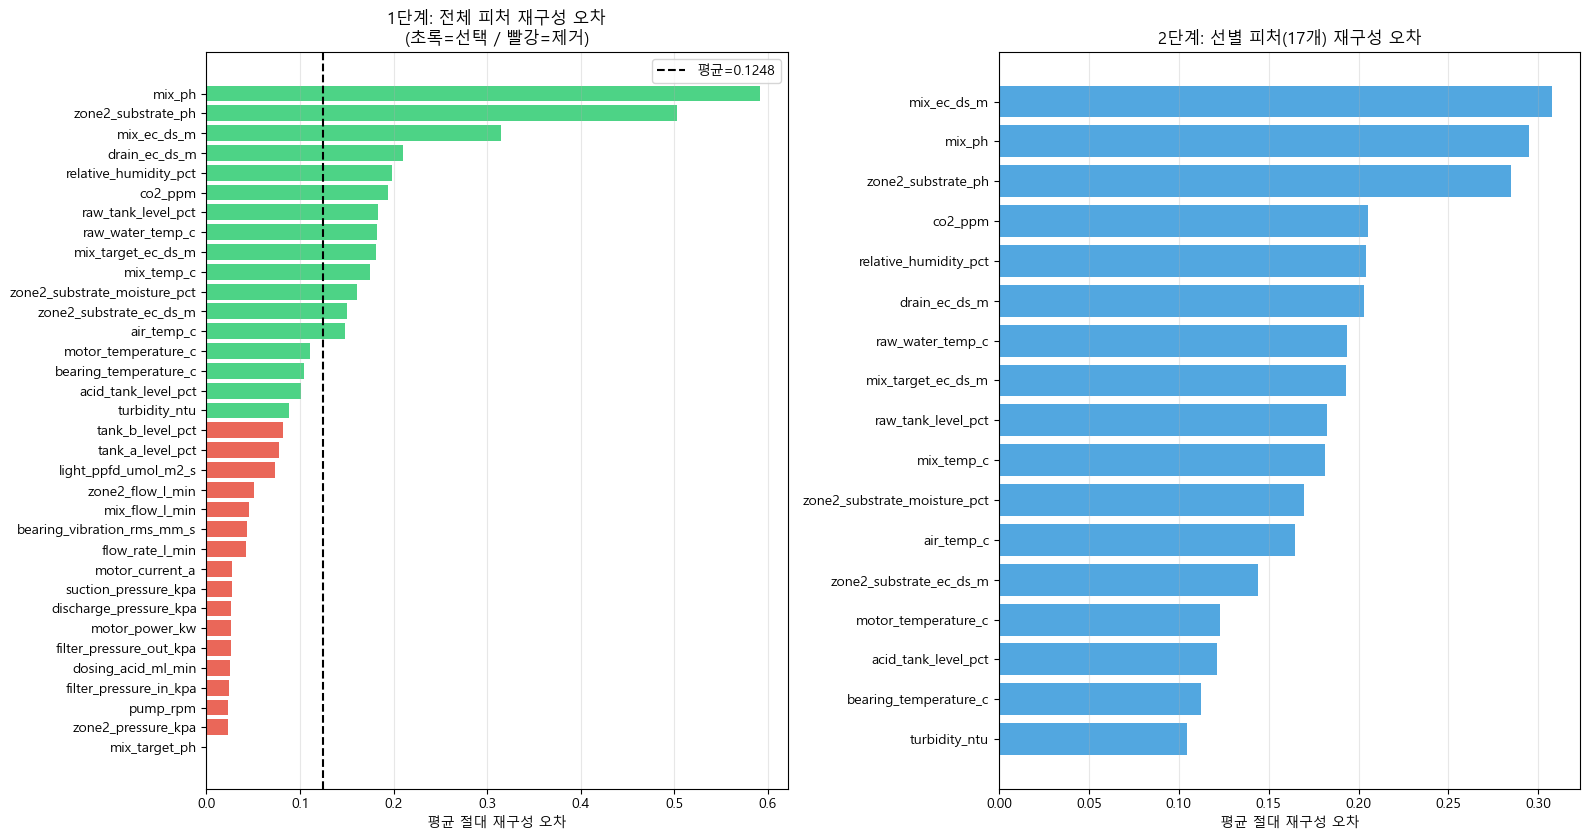


  ✅ 최종 선정 피처 17개
  - mix_ph
  - zone2_substrate_ph
  - mix_ec_ds_m
  - drain_ec_ds_m
  - relative_humidity_pct
  - co2_ppm
  - raw_tank_level_pct
  - raw_water_temp_c
  - mix_target_ec_ds_m
  - mix_temp_c
  - zone2_substrate_moisture_pct
  - zone2_substrate_ec_ds_m
  - air_temp_c
  - motor_temperature_c
  - bearing_temperature_c
  - acid_tank_level_pct
  - turbidity_ntu

SELECTED_FEATS = ['mix_ph', 'zone2_substrate_ph', 'mix_ec_ds_m', 'drain_ec_ds_m', 'relative_humidity_pct', 'co2_ppm', 'raw_tank_level_pct', 'raw_water_temp_c', 'mix_target_ec_ds_m', 'mix_temp_c', 'zone2_substrate_moisture_pct', 'zone2_substrate_ec_ds_m', 'air_temp_c', 'motor_temperature_c', 'bearing_temperature_c', 'acid_tank_level_pct', 'turbidity_ntu']


In [4]:
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 설정 ─────────────────────────────────────────────────────────
SEED       = 42
EPOCHS_1   = 300
PATIENCE_1 = 10
EPOCHS_2   = 150
BATCH      = 2048
LR         = 1e-3
NOISE      = 0.05
PATIENCE   = 10
TOP_RATIO  = 0.5
HIDDEN     = [32, 16, 8]

EXCLUDE = [
    'timestamp', 'crop_stage', 'flow_baseline_l_min',
    'cleaning_event_flag', 'hidden_tip_clog_level',
    'hidden_blocked_tip_ratio', 'hidden_risk_stage',
]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"디바이스: {device}")

# ── 데이터 로드 ───────────────────────────────────────────────────
df_raw = pd.read_csv("smartfarm_code/output/selected_smartfarm.csv", encoding="utf-8-sig")

# zone1, zone3 컬럼 제거 대상 추출
ZONE_DROP = [
    c for c in df_raw.columns
    if c.lower().startswith("zone1_") or c.lower().startswith("zone3_")
]

print("제거할 zone 컬럼:")
print(ZONE_DROP)

# 최종 제거 컬럼
FINAL_DROP = [c for c in EXCLUDE + ZONE_DROP if c in df_raw.columns]

print("\n최종 제거 컬럼:")
print(FINAL_DROP)

# 학습용 입력 생성
X_df = df_raw.drop(columns=FINAL_DROP, errors='ignore')
X_num = X_df.select_dtypes(include=[np.number]).dropna()
feats = X_num.columns.tolist()

print("\n남은 zone 컬럼:")
print([c for c in feats if c.lower().startswith("zone")])

scaler = RobustScaler().fit(X_num.values)
X_scaled = scaler.transform(X_num.values)

print(f"\n전체 피처: {len(feats)}개  샘플: {len(X_scaled):,}")

# ── 모델 정의 ─────────────────────────────────────────────────────
class DAE(nn.Module):
    def __init__(self, d):
        super().__init__()

        def blk(i, o):
            return [
                nn.Linear(i, o),
                nn.BatchNorm1d(o),
                nn.LeakyReLU(0.01, inplace=True),
                nn.Dropout(0.1)
            ]

        enc = []
        cur = d
        for u in HIDDEN:
            enc += blk(cur, u)
            cur = u
        self.enc = nn.Sequential(*enc)

        dec = []
        cur = HIDDEN[-1]
        for u in reversed(HIDDEN[:-1]):
            dec += blk(cur, u)
            cur = u
        dec.append(nn.Linear(cur, d))
        self.dec = nn.Sequential(*dec)

    def forward(self, x):
        return self.dec(self.enc(x))

def train_dae(X_arr, epochs, label=""):
    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_arr)),
        batch_size=BATCH,
        shuffle=True,
        pin_memory=(device.type == "cuda")
    )

    model = DAE(X_arr.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit = nn.MSELoss()

    best = float("inf")
    best_state = None
    wait = 0

    for ep in range(epochs):
        model.train()
        s = 0
        n = 0

        for (xb,) in loader:
            xb = xb.to(device)
            noisy = xb + NOISE * torch.randn_like(xb)

            opt.zero_grad(set_to_none=True)
            loss = crit(model(noisy), xb)
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            s += loss.item() * len(xb)
            n += len(xb)

        val = s / n
        sch.step(val)

        if val < best - 1e-6:
            best = val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if (ep + 1) % 10 == 0:
            print(f"  [{label}] ep{ep+1:3d}  loss={val:.5f}  wait={wait}")

        if wait >= PATIENCE:
            print(f"  EarlyStop @ ep{ep+1}")
            break

    model.load_state_dict(best_state)
    return model

@torch.no_grad()
def get_residuals(model, X_arr):
    model.eval()
    t = torch.FloatTensor(X_arr).to(device)
    return (model(t) - t).cpu().numpy()

# ══════════════════════════════════════════════════════════════════
# 1단계 — 전체 피처로 학습 → 재구성 오차로 피처 선별
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  1단계: 전체 피처 학습")
print("=" * 55)

model1 = train_dae(X_scaled, EPOCHS_1, label="1단계")
res1 = get_residuals(model1, X_scaled)
feat_err = np.abs(res1).mean(axis=0)

err_series = pd.Series(feat_err, index=feats).sort_values(ascending=False)
mean_err = err_series.mean()
top_n = max(5, int(len(feats) * TOP_RATIO))
selected = err_series.head(top_n).index.tolist()
dropped = err_series.tail(len(feats) - top_n).index.tolist()

print(f"\n  피처별 재구성 오차 (평균={mean_err:.5f})")
print(f"  {'피처':<45} {'오차':>8}  {'선택'}")
print("  " + "-" * 60)

for feat, err in err_series.items():
    mark = "✅ 선택" if feat in selected else "❌ 제거"
    bar = "█" * int(err / err_series.max() * 20)
    print(f"  {feat:<45} {err:.5f}  {mark}  {bar}")

print(f"\n  선택: {len(selected)}개 / 제거: {len(dropped)}개")
print(f"  제거 피처: {dropped}")

# ══════════════════════════════════════════════════════════════════
# 2단계 — 선별 피처만으로 정밀 학습
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  2단계: 선별 피처로 정밀 학습")
print("=" * 55)

sel_idx = [feats.index(f) for f in selected]
X_sel = X_scaled[:, sel_idx]
scaler2 = RobustScaler().fit(X_num[selected].values)
X_sel_sc = scaler2.transform(X_num[selected].values)

model2 = train_dae(X_sel_sc, EPOCHS_2, label="2단계")
res2 = get_residuals(model2, X_sel_sc)
feat_err2 = pd.Series(np.abs(res2).mean(axis=0), index=selected).sort_values(ascending=False)

# ── 시각화 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(feats) * 0.25)))

ax = axes[0]
colors = ['#2ecc71' if f in selected else '#e74c3c' for f in err_series.index]
ax.barh(err_series.index[::-1], err_series.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(mean_err, color='black', ls='--', lw=1.5, label=f'평균={mean_err:.4f}')
ax.set_title("1단계: 전체 피처 재구성 오차\n(초록=선택 / 빨강=제거)")
ax.set_xlabel("평균 절대 재구성 오차")
ax.legend()
ax.grid(axis='x', alpha=.3)

ax2 = axes[1]
ax2.barh(feat_err2.index[::-1], feat_err2.values[::-1], color='#3498db', alpha=0.85)
ax2.set_title(f"2단계: 선별 피처({len(selected)}개) 재구성 오차")
ax2.set_xlabel("평균 절대 재구성 오차")
ax2.grid(axis='x', alpha=.3)

plt.tight_layout()
plt.savefig("output_m/feature_selection_ae.png", dpi=130, bbox_inches='tight')
plt.show()

print(f"\n{'=' * 55}")
print(f"  ✅ 최종 선정 피처 {len(selected)}개")
print(f"{'=' * 55}")
for f in selected:
    print(f"  - {f}")

print(f"\nSELECTED_FEATS = {selected}")